# 04 Retention Cohorts

## Goal

Build weekly cohorts and retention views to understand whether users come back after first activity or purchase.

## Setup

Connect to the local DuckDB database created by the transformation pipeline.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from product_growth_analytics.notebook_utils import connect, query_df, read_sql

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
con = connect()

## Concept

Retention is cohort users who return in a later period divided by the original cohort size. The denominator stays fixed for each cohort.

In [2]:
retention = query_df(con, read_sql("analysis/retention.sql"))
retention.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,cohort_week,week_number,retained_users,cohort_users,retention_rate
0,2019-09-30,0,851711,851711,1.0000
1,2019-09-30,1,303632,851711,0.3565
2,2019-09-30,2,273387,851711,0.3210
3,2019-09-30,3,236732,851711,0.2779
4,2019-09-30,4,225837,851711,0.2652


In [3]:
retention_pivot = retention.pivot(index="cohort_week", columns="week_number", values="retention_rate")
retention_pivot

week_number,0,1,2,3,4,5,6,7,8
cohort_week,,,,,,,,,
2019-09-30,1.0000,0.3565,0.3210,0.2779,0.2652,0.2943,0.3200,0.2402,0.2141
2019-10-07,1.0000,0.2716,0.2210,0.2039,0.2361,0.2597,0.1862,0.1652,NaN
2019-10-14,1.0000,0.2242,0.1842,0.2089,0.2302,0.1628,0.1403,NaN,NaN
2019-10-21,1.0000,0.1886,0.1851,0.1922,0.1435,0.1194,NaN,NaN,NaN
2019-10-28,1.0000,0.2201,0.2076,0.1462,0.1216,NaN,NaN,NaN,NaN
2019-11-04,1.0000,0.2518,0.1597,0.1277,NaN,NaN,NaN,NaN,NaN
2019-11-11,1.0000,0.2102,0.1499,NaN,NaN,NaN,NaN,NaN,NaN
2019-11-18,1.0000,0.1531,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-11-25,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


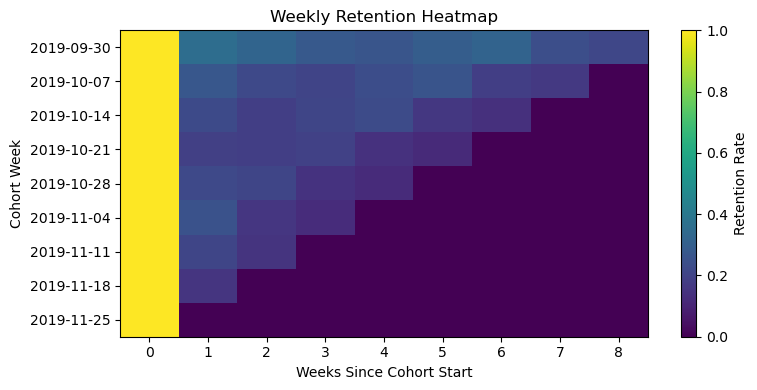

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(retention_pivot.fillna(0), aspect="auto")
ax.set_title("Weekly Retention Heatmap")
ax.set_xlabel("Weeks Since Cohort Start")
ax.set_ylabel("Cohort Week")
ax.set_xticks(range(len(retention_pivot.columns)))
ax.set_xticklabels(retention_pivot.columns)
ax.set_yticks(range(len(retention_pivot.index)))
ax.set_yticklabels([str(x.date()) if hasattr(x, "date") else str(x) for x in retention_pivot.index])
fig.colorbar(im, ax=ax, label="Retention Rate")
plt.tight_layout()

In [5]:
repeat_purchase = query_df(con, """
WITH purchase_days AS (
    SELECT user_id, COUNT(DISTINCT purchase_date) AS distinct_purchase_days
    FROM analytics.fact_purchases
    GROUP BY 1
)
SELECT
    COUNT(*) AS purchasers,
    SUM(CASE WHEN distinct_purchase_days >= 2 THEN 1 ELSE 0 END) AS repeat_purchasers,
    SUM(CASE WHEN distinct_purchase_days >= 2 THEN 1 ELSE 0 END) * 1.0 / COUNT(*) AS repeat_purchase_rate
FROM purchase_days
""")
repeat_purchase

,purchasers,repeat_purchasers,repeat_purchase_rate
0,697470,209188.0000,0.2999


## Takeaways

- The original retention query was corrected so each cohort period uses the **original cohort size** as the denominator. This is essential because retention should not divide by only the users who returned.
- Week 1 retention is strongest for the first observed cohort: the **2019-09-30 cohort retained 35.65%** of users in Week 1. Later cohorts generally show lower Week 1 retention, ranging from about **15% to 27%**.
- Retention declines as cohorts age, which is expected, but there are bumps around the mid-November period. These should be interpreted carefully because November 15-17 is a known purchase/revenue anomaly window.
- Repeat purchase is a meaningful lifecycle signal: **209,188 of 697,470 purchasers** bought on at least two distinct purchase days, giving a **29.99% repeat purchase rate**.
- This means roughly 3 in 10 buyers show repeat purchase behavior within the two-month observation window, which is strong enough to support deeper lifecycle and revenue analysis.
- Product recommendations should focus on what differentiates repeat purchasers from one-time purchasers: categories viewed, cart behavior, purchase frequency, brand/category breadth, and first-purchase experience.

Overall, retention exists but decays meaningfully after the first active week. The strongest growth opportunity is not only acquiring users, but increasing repeat engagement and repeat purchase after the first purchase.